In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, yaml, os

import tensorflow as tf
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from msfm.fiducial_pipeline import FiducialPipeline
from msfm.utils import files, parameters, logger

from deep_lss.models.delta_model import DeltaLossModel
from deep_lss.nets import resnet
from deep_lss.utils import configuration, delta_loss

LOGGER = logger.get_logger("temp")

24-03-14 02:42:08   imports.py INF   Setting up healpy to run on 32 CPUs 
24-03-14 02:42:08   imports.py INF   Setting up healpy to run on 32 CPUs 


In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")

# training loss = -50.356048583984375
# validation loss = -43.50503921508789
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"
# model_dir = os.path.join(base_dir, "delta/2024-01-12_19-35-59_resnet_vanilla")

# training loss = -50.67667007446289
# validation loss = 24.448930740356445
# base_dir = "/pscratch/sd/a/athomsen/run_files/v7/lensing"
# model_dir = os.path.join(base_dir, "delta/2024-02-22_03-37-44_resnet_vanilla")

# cosine decay learning rate schedule
# training loss = -55.834678649902344
# validation loss = 22.466981887817383
# base_dir = "/pscratch/sd/a/athomsen/run_files/v7/lensing"
# model_dir =  os.path.join(base_dir, "delta/2024-02-29_05-09-44_resnet_vanilla")

# constant learning rate
# training loss = -44.3000373840332
# validation loss = 14.402016639709473
# base_dir = "/pscratch/sd/a/athomsen/run_files/v7/lensing"
# model_dir =  os.path.join(base_dir, "delta/2024-03-02_10-21-45_resnet_vanilla")

# icy-vortex-344
# cosine decay, but reasonable validation loss, jac_weight = 10
# training loss = -65.46736907958984
# validation loss = -18.688838958740234
# base_dir = "/pscratch/sd/a/athomsen/run_files/v7/lensing"
# model_dir = os.path.join(base_dir, "delta/2024-03-13_03-40-37_resnet_vanilla")

# skilled-salad-343
# cosine decay, but reasonable validation loss, jac_weight = 100
# training loss = -58.87385559082031
# validation loss = -19.380346298217773
base_dir = "/pscratch/sd/a/athomsen/run_files/v7/lensing"
model_dir = os.path.join(base_dir, "delta/2024-03-13_03-40-30_resnet_vanilla")

params = ["Om", "s8", "w0", "Aia", "n_Aia"]
perts = parameters.get_fiducial_perturbations(params, conf)

with open(os.path.join(model_dir, "configs.yaml"), "r") as f:
    net_conf, dlss_conf, msfm_conf = list(yaml.load_all(f, Loader=yaml.FullLoader))

In [4]:
version = "v7"
bias = "linear_bias"

fidu_pipe = FiducialPipeline(
    conf=conf,
    params=params,
    with_lensing=True,
    with_clustering=False,
    with_padding=True,
    apply_norm=True,
)

n_side = 512
data_vec_pix = fidu_pipe.data_vec_pix
n_z_bins = 4
n_params= len(params)
local_batch_size = 32

train_pattern = f"/pscratch/sd/a/athomsen/DESY3/{version}/{bias}/tfrecords/fiducial/DESy3_fiducial_????.tfrecord"
train_dset = fidu_pipe.get_dset(
    tfr_pattern=train_pattern,
    local_batch_size=local_batch_size,
    noise_indices=3,
    n_readers=1,
    is_eval=True,
    drop_remainder=True,
    n_prefetch=1,
)

vali_pattern = f"/pscratch/sd/a/athomsen/DESY3/{version}/{bias}/tfrecords/fiducial/validation/DESy3_fiducial_????.tfrecord"
vali_dset = fidu_pipe.get_dset(
    tfr_pattern=vali_pattern,
    local_batch_size=local_batch_size,
    noise_indices=3,
    n_readers=1,
    is_eval=True,
    drop_remainder=True,
    n_prefetch=1,
)


24-03-14 02:42:10     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
24-03-14 02:42:10     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
24-03-14 02:42:12 fiducial_pip WAR   Evaluation mode is activated: the random seed is fixed, the shuffle arguments ignored, and the dataset is not repeated 
24-03-14 02:42:12 fiducial_pip INF   n_workers is not set, using tf.data.AUTOTUNE. This might produce unexpected RAM usage. 
24-03-14 02:42:12 fiducial_pip INF   Including noise_indices = [0, 1, 2] 
24-03-14 02:42:12 fiducial_pip INF   Interleaving with n_readers = 1 
24-03-14 02:42:12 fiducial_pip INF   Batching into 32 elements locally with drop_remainder = True 
24-03-14 02:42:13 fiducial_pip WAR   Tracing _augmentations 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=1

In [5]:
smoothing_kwargs = configuration.get_smoothing_kwargs(
    "delta", msfm_conf, dlss_conf, net_conf, dir_base=base_dir
)

network = resnet.ResNetLayers(
    out_dim=n_params, smoothing_kwargs=smoothing_kwargs, **net_conf["network"]["kwargs"]
).get_layers()

model = DeltaLossModel(
    network=network,
    n_side=n_side,
    indices=data_vec_pix,
    n_neighbors=net_conf["network"]["n_neighbors"],
    checkpoint_dir=os.path.join(model_dir, "checkpoint"),
    max_batch_size=(2*n_params+1)*local_batch_size,
    input_shape=(None, len(data_vec_pix), n_z_bins),
    restore_checkpoint=True,
    summary_dir="/pscratch/sd/a/athomsen/debug/overfitting",
    strategy=None,
)

# model.setup_delta_loss_step(
#     n_params,
#     local_batch_size,
#     perts,
#     n_channels=n_z_bins,
#     **dlss_conf["delta_loss"],
#     **net_conf["optimization"]["gradient_clipping"],
# )

delta_non_regu_fn = lambda preds: delta_loss.delta_loss(
    preds,
    n_params=n_params,
    n_same=local_batch_size,
    n_output=n_params,
    off_sets=perts,
    force_params_value=None,
    jac_weight=None,
    jac_cond_weight=None,
    tikhonov_regu=False,
    training=False,
    strategy=None,
)


24-03-14 02:42:14     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
24-03-14 02:42:15     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
Using the per channel smoothing repetitions [6 3 2 1]
Using the per channel smoothing scales sigma = [9.78 6.91 5.65 3.99] arcmin, fwhm = [23.03 16.28 13.29  9.4 ] arcmin
Successfully loaded sparse kernel indices and values from /pscratch/sd/a/athomsen/run_files/v7/lensing/smoothing
Successfully created the sparse kernel tensor
24-03-14 02:42:15 base_model.p INF   Initializing with a HealpyGCNN model 
Detected a reduction factor of 32.0, the input with nside 512 will be transformed to 16 during a forward pass. Checking for consistency with indices...
indices seem consistent...
Successfully built the smoothing layer
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 4 splits. Bew

In [6]:
@tf.function
def loss_fn(batch):
    preds = model(batch)
    # loss = model.loss_fn(preds)
    loss = delta_non_regu_fn(preds)
    return loss    

In [7]:
losses = []
# for batch, _ in LOGGER.progressbar(train_dset.take(5)):
for batch, _ in LOGGER.progressbar(train_dset):
    loss = loss_fn(batch)
    # print(f"total_loss: {loss}")
    losses.append(loss)
    
losses = tf.stack(losses, axis=0)
losses = tf.reduce_mean(losses)
print(f"training loss = {losses}")


  0%|                            |   | 0/? [00:00<?, ?it/s]                   24-03-14 02:42:27 delta_loss.p WAR   Tracing delta_loss 


2024-03-14 02:42:34.318356: W tensorflow/core/kernels/gpu_utils.cc:50] Failed to allocate memory for convolution redzone checking; skipping this check. This is benign and only means that we won't check cudnn for out-of-bounds reads and writes. This message will only be printed once.


  0%|                            |   | 67/? [03:12<00:00,  2.88s/it]          
training loss = -58.87385559082031


In [8]:
losses = []
for batch, _ in LOGGER.progressbar(vali_dset.take(5)):
    loss = loss_fn(batch)
    # print(f"total_loss: {loss}")
    losses.append(loss)
    
losses = tf.stack(losses, axis=0)
losses = tf.reduce_mean(losses)
print(f"validation loss = {losses}")


  0%|                            |   | 5/? [00:20<00:00,  4.15s/it]           
validation loss = -19.380346298217773


# histograms

In [9]:
version = "v7"
bias = "linear_bias"

fidu_pipe_hist = FiducialPipeline(
    conf=conf,
    params=[],
    with_lensing=True,
    with_clustering=False,
    with_padding=True,
    apply_norm=True,
)

n_side = 512
data_vec_pix = fidu_pipe.data_vec_pix
n_z_bins = 4
n_params= len(params)
local_batch_size = 32

train_pattern = f"/pscratch/sd/a/athomsen/DESY3/{version}/{bias}/tfrecords/fiducial/DESy3_fiducial_????.tfrecord"
train_dset_hist = fidu_pipe_hist.get_dset(
    tfr_pattern=train_pattern,
    local_batch_size=local_batch_size,
    noise_indices=3,
    n_readers=1,
    is_eval=True,
    n_prefetch=1,
)

vali_pattern = f"/pscratch/sd/a/athomsen/DESY3/{version}/{bias}/tfrecords/fiducial/validation/DESy3_fiducial_????.tfrecord"
vali_dset_hist = fidu_pipe_hist.get_dset(
    tfr_pattern=vali_pattern,
    local_batch_size=local_batch_size,
    noise_indices=3,
    n_readers=1,
    is_eval=True,
    n_prefetch=1,
)

24-03-14 02:45:52     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
24-03-14 02:45:52     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
24-03-14 02:45:53 fiducial_pip WAR   Evaluation mode is activated: the random seed is fixed, the shuffle arguments ignored, and the dataset is not repeated 
24-03-14 02:45:53 fiducial_pip INF   n_workers is not set, using tf.data.AUTOTUNE. This might produce unexpected RAM usage. 
24-03-14 02:45:53 fiducial_pip INF   drop_remainder is not set, using drop_remainder = False 
24-03-14 02:45:53 fiducial_pip INF   Including noise_indices = [0, 1, 2] 
24-03-14 02:45:53 fiducial_pip INF   Interleaving with n_readers = 1 
24-03-14 02:45:53 fiducial_pip INF   Batching into 32 elements locally with drop_remainder = False 
24-03-14 02:45:53 fiducial_pip WAR   Tracing _augmentations 
24-03-14 02:45:53 fiducial_pip IN

In [10]:
train_preds = []
for batch, _ in LOGGER.progressbar(train_dset_hist):
    train_preds.append(model.tf_call(batch))
    
train_preds = tf.concat(train_preds, axis=0)
train_preds = train_preds.numpy()

  0%|                            |   | 0/? [00:00<?, ?it/s]                   24-03-14 02:45:55 base_model.p WAR   Tracing tf_call 
  0%|                            |   | 67/? [01:32<00:00,  1.33s/it]          24-03-14 02:47:26 base_model.p WAR   Tracing tf_call 
  0%|                            |   | 68/? [01:33<00:00,  1.37s/it]          


In [11]:
vali_preds = []
for batch, _ in LOGGER.progressbar(vali_dset_hist):
    vali_preds.append(model.tf_call(batch))
    
vali_preds = tf.concat(vali_preds, axis=0)
vali_preds = vali_preds.numpy()

  0%|                            |   | 8/? [00:11<00:00,  1.45s/it]           


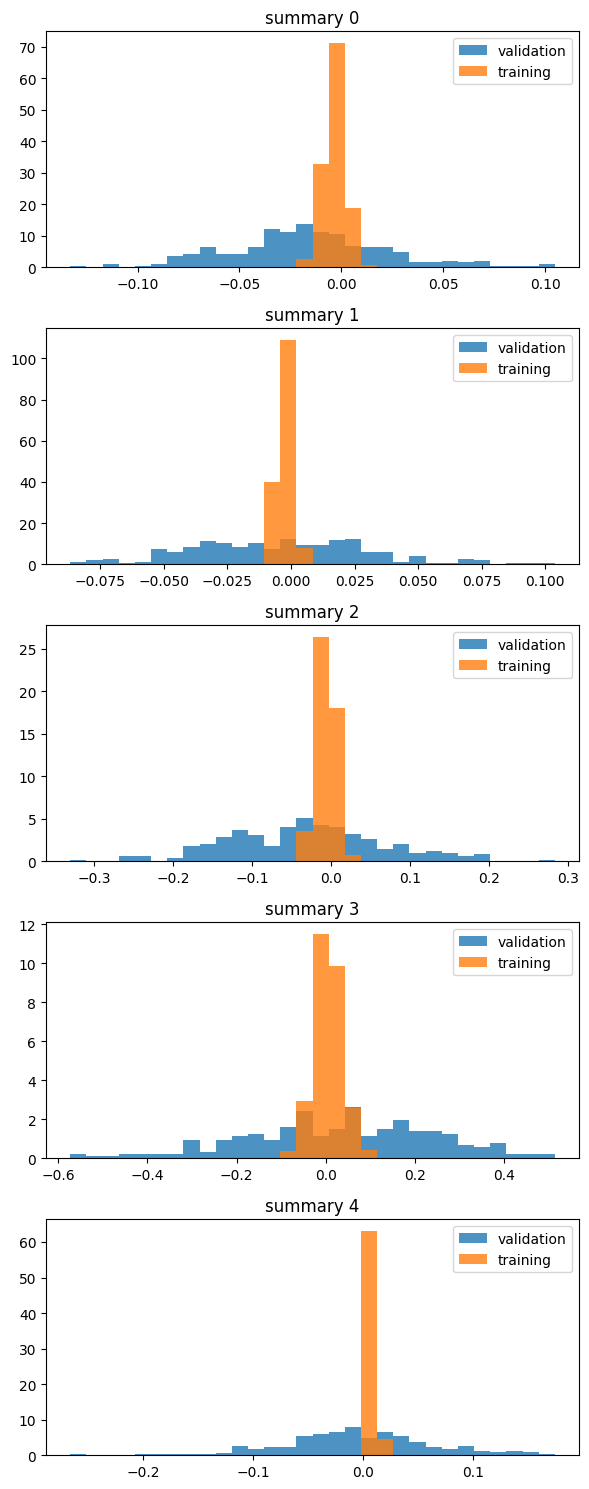

In [12]:
n_summaries = vali_preds.shape[1]

fig, ax = plt.subplots(nrows=n_summaries, figsize=(6, 3*n_summaries))

for i in range(n_summaries):
    _, bins, _ = ax[i].hist(vali_preds[:,i], bins=30, label="validation", density=True, alpha=0.8)
    _ = ax[i].hist(train_preds[:,i], bins=bins, label="training", density=True, alpha=0.8)

    ax[i].set(title=f"summary {i}")
    ax[i].legend()
    
plt.tight_layout()

# covariances

In [13]:
# train_cov = np.cov(train_preds, rowvar=False)
# vali_cov = np.cov(vali_preds, rowvar=False)
# cross_cov = np.cov(train_preds[:vali_preds.shape[0]], y=vali_preds, rowvar=False)

# vmin = np.min(np.array([train_cov.min(), vali_cov.min(), cross_cov.min()]))
# vmax = np.max(np.array([train_cov.max(), vali_cov.max(), cross_cov.max()]))

# fig, ax = plt.subplots(figsize=(15,5), ncols=3)

# im = ax[0].matshow(train_cov, vmin=vmin, vmax=vmax)
# ax[0].set(title="training set covariance")
# # fig.colorbar(im, ax=ax[0], orientation="horizontal")

# im = ax[1].matshow(vali_cov, vmin=vmin, vmax=vmax)
# ax[1].set(title="validation set covariance")
# # fig.colorbar(im, ax=ax[1], orientation="horizontal")

# im = ax[2].matshow(cross_cov, vmin=vmin, vmax=vmax)
# ax[2].set(title="cross covariance")

# fig.colorbar(im, ax=ax, orientation="horizontal")


In [14]:
# train_corr = np.corrcoef(train_preds, rowvar=False)
# vali_corr = np.corrcoef(vali_preds, rowvar=False)
# cross_corr = np.corrcoef(train_preds[:vali_preds.shape[0]], y=vali_preds, rowvar=False)

# vmin = -1
# vmax = 1

# fig, ax = plt.subplots(figsize=(15,5), ncols=3)

# im = ax[0].matshow(train_corr, vmin=vmin, vmax=vmax)
# ax[0].set(title="training set correlation")
# # fig.colorbar(im, ax=ax[0], orientation="horizontal")

# im = ax[1].matshow(vali_corr, vmin=vmin, vmax=vmax)
# ax[1].set(title="validation set correlation")
# # fig.colorbar(im, ax=ax[1], orientation="horizontal")

# im = ax[2].matshow(cross_corr, vmin=vmin, vmax=vmax)
# ax[2].set(title="cross correlation")

# fig.colorbar(im, ax=ax, orientation="horizontal")
